# Tarea pratica final de NLP

## IMPORT PACKAGES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

### IMPORT DATA

In [2]:
data = pd.read_csv('fake_factual_news_dataset.csv',sep= ";", engine='python')

In [3]:
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"

In [4]:
data.head()

,title,text,date,fake_or_factual
0,Researchers develop improved battery technology,According to an official statement released to...,2016-03-21 0:00:00,Factual News
1,New environmental regulations introduced by pa...,"The report includes verified data, statements ...",2020-04-21 0:00:00,Factual News
2,"Drinking hot water instantly burns body fat, e...",The story spread rapidly on social media with ...,2020-04-30 0:00:00,Fake News
3,Economic growth shows moderate increase this q...,The findings were published in a peer‑reviewed...,2017-11-04 0:00:00,Factual News
4,Ocean discovered to contain unlimited gold res...,The story spread rapidly on social media with ...,2022-01-10 0:00:00,Fake News


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            200 non-null    object
 1   text             200 non-null    object
 2   date             200 non-null    object
 3   fake_or_factual  200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


Text(0.5, 0, 'Classification')

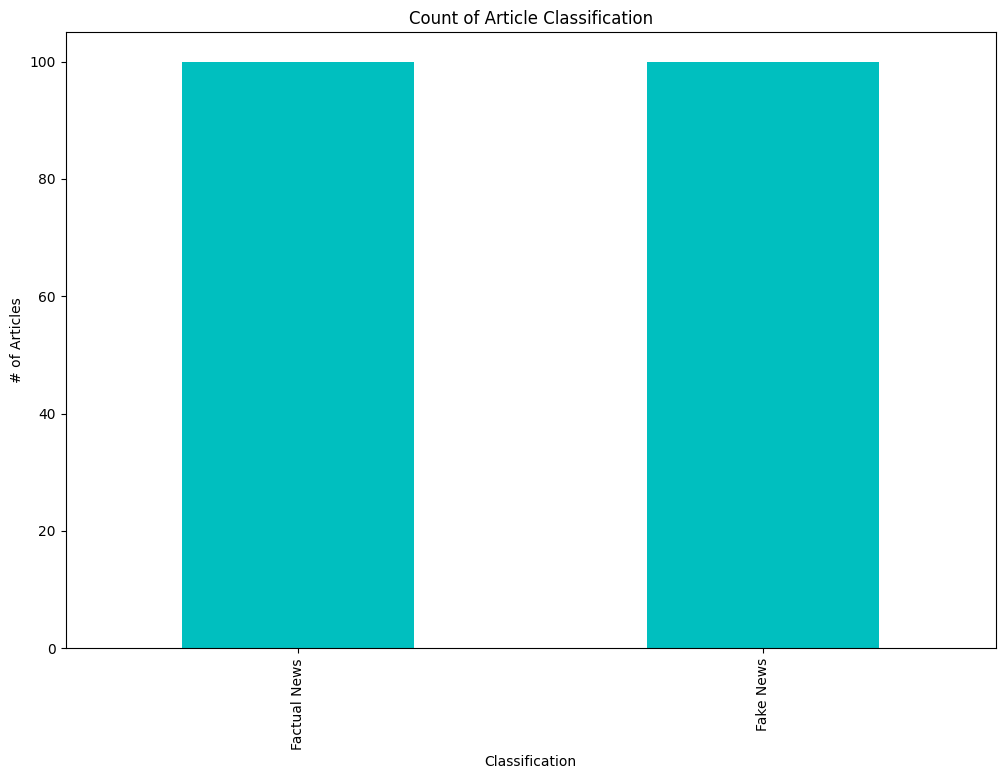

In [6]:
data['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title('Count of Article Classification')
plt.ylabel('# of Articles')
plt.xlabel('Classification')
## número de trama de artículos falsos y factuales

## Pos Tagging

In [7]:
nlp = spacy.load("en_core_web_sm")

In [8]:
# datos de noticias falsas y verdaderas
fake_news = data[data['fake_or_factual'] == "Fake News"]
fact_news = data[data['fake_or_factual'] == "Factual News"]

In [9]:
# crear documentos espaciales - usar canalización para el marco de datos
fake_spaceydocs = list(nlp.pipe(fake_news['text']))
fact_spaceydocs = list(nlp.pipe(fact_news['text'])) 

In [10]:
# crear función para extraer etiquetas para cada documento en nuestros datos
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [11]:
# etiqueta conjunto de datos falso
fake_tagsdf = []
columns = ["token", "ner_tag", "pos_tag"]

for ix, doc in enumerate(fake_spaceydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)
        
fake_tagsdf = pd.concat(fake_tagsdf)  

In [12]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,The,,DET
1,story,,NOUN
2,spread,,VERB
3,rapidly,,ADV
4,on,,ADP


In [13]:
# etiqueta conjunto de datos verdaderos 
fact_tagsdf = []

for ix, doc in enumerate(fact_spaceydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)
        
fact_tagsdf = pd.concat(fact_tagsdf)   

In [14]:
 fact_tagsdf.head()       

,token,ner_tag,pos_tag
0,According,,VERB
1,to,,ADP
2,an,,DET
3,official,,ADJ
4,statement,,NOUN


In [15]:
# recuento de frecuencia de tokens (falso)
pos_counts_fake = fake_tagsdf.groupby(['token','pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
pos_counts_fake.head(5)

,token,pos_tag,counts
58,the,DET,131
1,.,PUNCT,100
0,",",PUNCT,56
11,article,NOUN,48
14,but,CCONJ,44


In [16]:
# recuento de frecuencia de tokens (hecho)
pos_counts_fact = fact_tagsdf.groupby(['token','pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
pos_counts_fact.head(5)

,token,pos_tag,counts
1,.,PUNCT,100
4,The,DET,62
8,and,CCONJ,59
0,",",PUNCT,57
5,a,DET,42


In [17]:
# frecuencias de etiquetas pos
pos_counts_fake.groupby(['pos_tag'])['token'].count().sort_values(ascending=False).head(5)

pos_tag
NOUN    19
ADJ     13
VERB    11
ADP      5
DET      5
Name: token, dtype: int64

In [18]:
pos_counts_fact.groupby(['pos_tag'])['token'].count().sort_values(ascending=False).head(5)

pos_tag
NOUN    26
VERB    10
ADP      6
ADJ      5
DET      4
Name: token, dtype: int64

In [19]:
# Profundizar en las diferencias entre los sustantivos
pos_counts_fake[pos_counts_fake.pos_tag == "NOUN"][0:15]

,token,pos_tag,counts
11,article,NOUN,48
28,information,NOUN,37
16,claim,NOUN,32
21,discovery,NOUN,24
29,institutions,NOUN,24
55,statements,NOUN,24
19,context,NOUN,24
4,Images,NOUN,24
17,claims,NOUN,24
53,sources,NOUN,20


In [20]:
pos_counts_fact[pos_counts_fact.pos_tag == "NOUN"][0:15]

,token,pos_tag,counts
38,policy,NOUN,38
13,conference,NOUN,24
39,press,NOUN,24
46,representatives,NOUN,24
9,announcement,NOUN,24
26,government,NOUN,24
25,goals,NOUN,21
33,market,NOUN,21
17,decision,NOUN,21
22,expectations,NOUN,21


## Entidades nombradas

In [21]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != ""] \
                    .groupby(['token','ner_tag']).size().reset_index(name='counts') \
                    .sort_values(by='counts', ascending=False)

In [22]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag'] != ""] \
                    .groupby(['token','ner_tag']).size().reset_index(name='counts') \
                    .sort_values(by='counts', ascending=False)

In [23]:
# Cree una paleta personalizada para garantizar que los gráficos sean consistentes


In [24]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

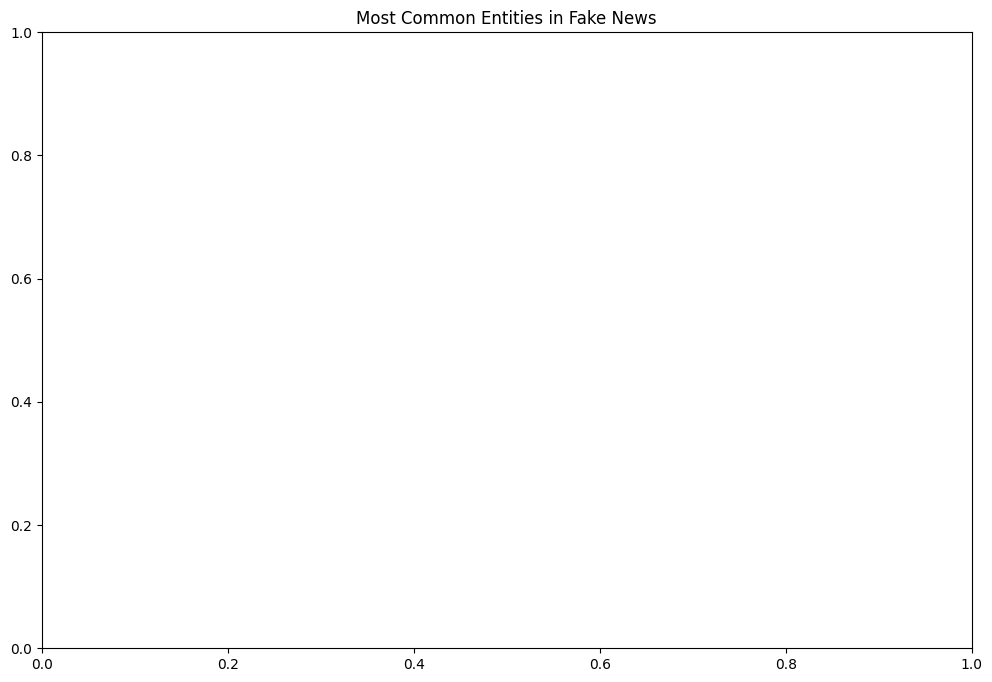

In [25]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most Common Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Entities in Factual News')]

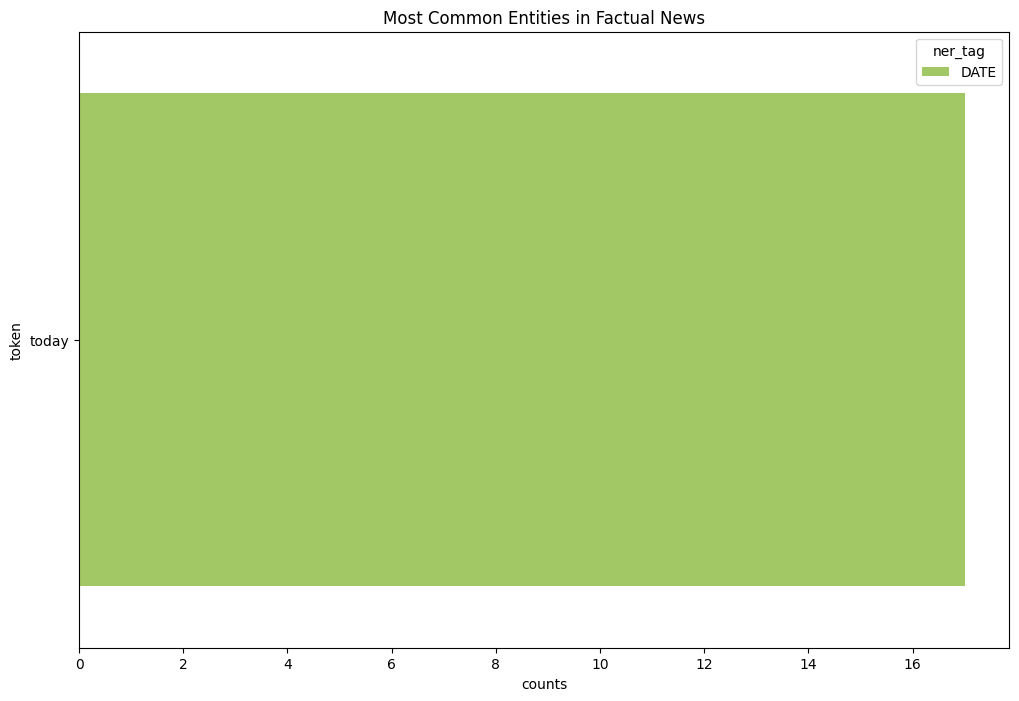

In [26]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most Common Entities in Factual News')

## Preprocesamiento de texto

In [27]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s*", "", x['text']), axis=1)

In [28]:
data['text_clean'] = data['text_clean'].str.lower()
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text_clean']), axis=1)
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [29]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis=1)
lemmatizer = WordNetLemmatizer()
data["text_clean"] = data["text_clean"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [30]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,Researchers develop improved battery technology,According to an official statement released to...,2016-03-21 0:00:00,Factual News,"[according, official, statement, released, tod..."
1,New environmental regulations introduced by pa...,"The report includes verified data, statements ...",2020-04-21 0:00:00,Factual News,"[report, includes, verified, data, statement, ..."
2,"Drinking hot water instantly burns body fat, e...",The story spread rapidly on social media with ...,2020-04-30 0:00:00,Fake News,"[story, spread, rapidly, social, medium, drama..."
3,Economic growth shows moderate increase this q...,The findings were published in a peer‑reviewed...,2017-11-04 0:00:00,Factual News,"[finding, published, peerreviewed, journal, re..."
4,Ocean discovered to contain unlimited gold res...,The story spread rapidly on social media with ...,2022-01-10 0:00:00,Fake News,"[story, spread, rapidly, social, medium, drama..."


In [31]:
tokens_clean = sum(data['text_clean'], [])
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()).reset_index()[:10]
print(unigrams)

            index  count
0    (statement,)     61
1        (claim,)     56
2     (official,)     56
3    (confirmed,)     48
4      (article,)     48
5       (online,)     43
6       (report,)     39
7       (policy,)     38
8  (information,)     37
9       (expert,)     34


C:\Users\pc\AppData\Local\Temp\ipykernel_7088\4019870307.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = "count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

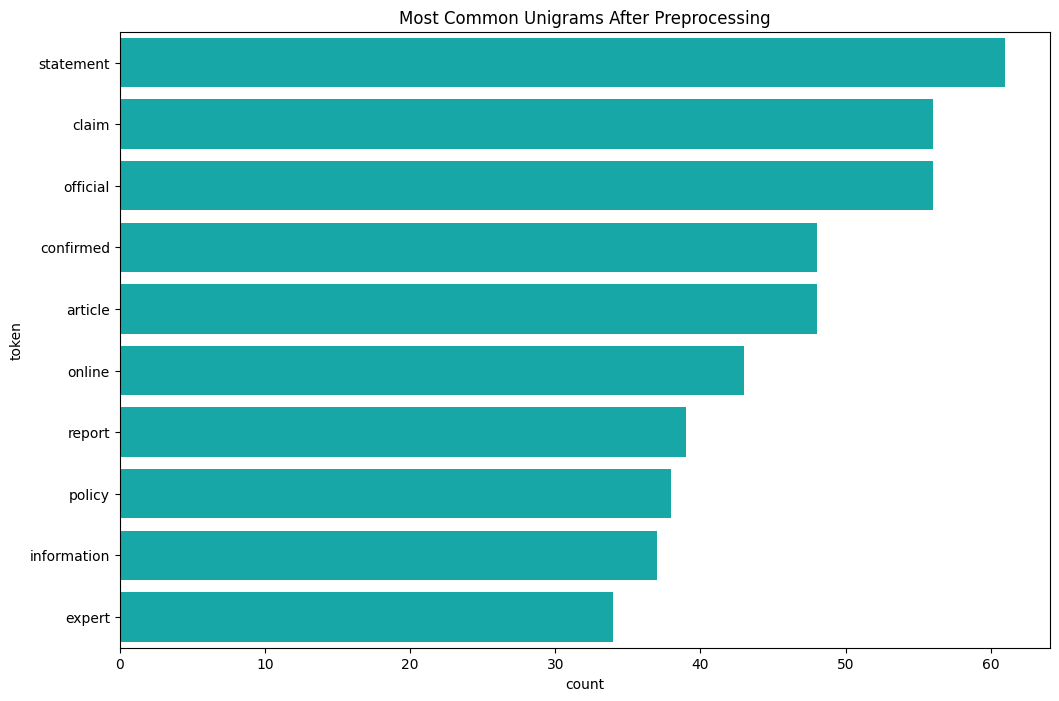

In [32]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0]) # extract the token from the tuple so we can plot it

sns.barplot(x = "count", 
            y = "token", 
            data=unigrams,
            orient = 'h',
            palette=[default_plot_colour],
            hue = "token", legend = False)\
.set(title='Most Common Unigrams After Preprocessing')

In [33]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()) 
print(bigrams[:10])

(expert, say)                   34
(discovery, scientific)         24
(circulating, online)           24
(article, circulating)          24
(revolutionary, discovery)      24
(announcement, confirmed)       24
(confirmed, government)         24
(government, representative)    24
(representative, press)         24
(press, conference)             24
Name: count, dtype: int64


## Análisis de sentimientos

In [34]:
vader_sentiment = SentimentIntensityAnalyzer()

In [35]:
data['vader_sentiment_score'] = data['text'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])

In [36]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)

<Axes: xlabel='vader_sentiment_label'>

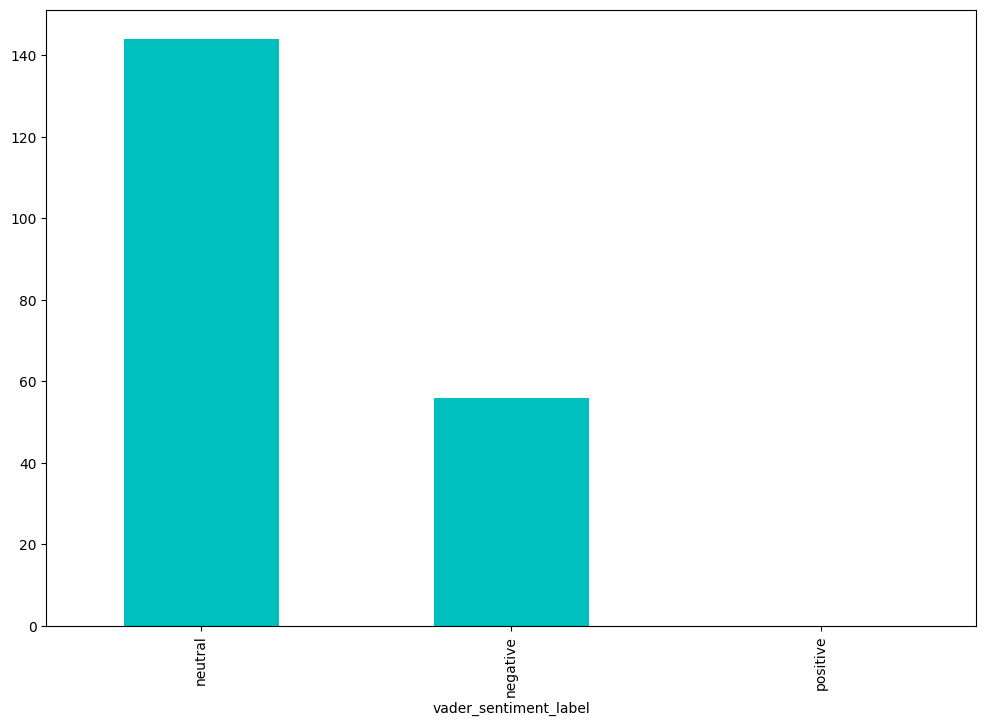

In [37]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

C:\Users\pc\AppData\Local\Temp\ipykernel_7088\3014756626.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

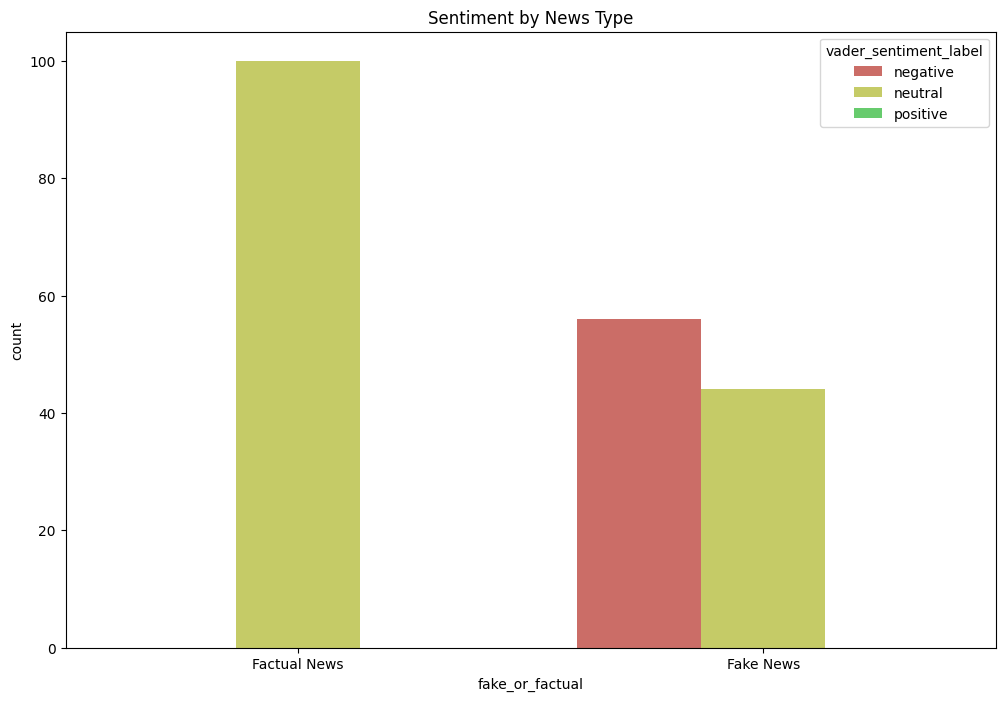

In [38]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette("hls"),
    data = data
) \
.set(title='Sentiment by News Type')

## LDA 

In [39]:
fake_news_text = data[data['fake_or_factual'] == "Fake News"]['text_clean'].reset_index(drop=True)
dictionary_fake = corpora.Dictionary(fake_news_text)
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

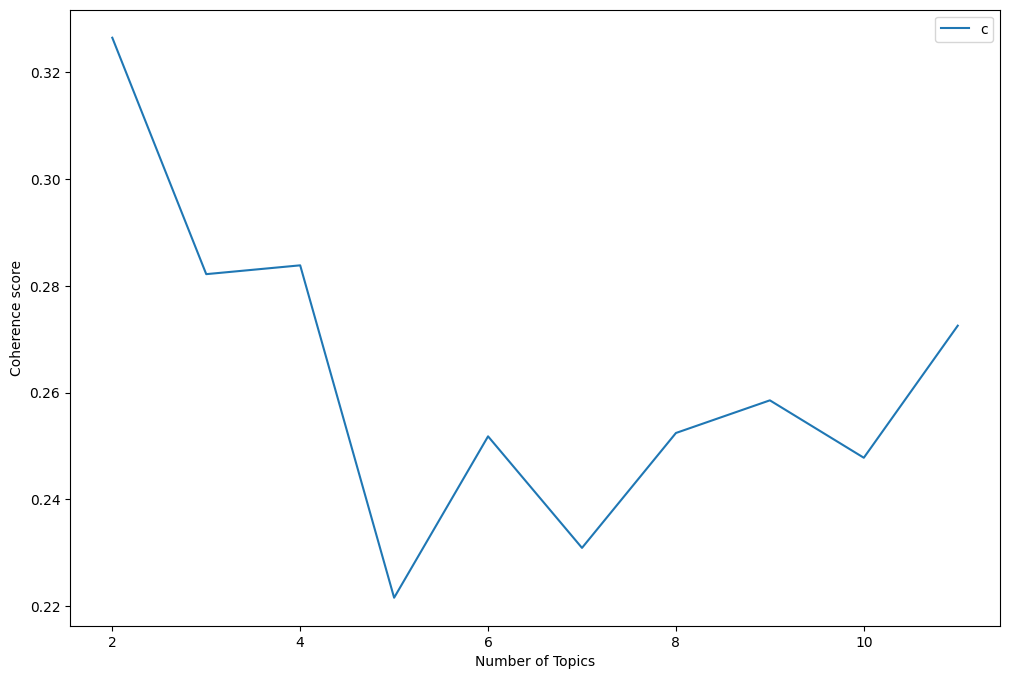

In [40]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=num_topics_i, id2word = dictionary_fake)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())
    
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [41]:
num_topics_fake = 6 

lda_model_fake = gensim.models.LdaModel(corpus=doc_term_fake,
                                       id2word=dictionary_fake,
                                       num_topics=num_topics_fake)

lda_model_fake.print_topics(num_topics=num_topics_fake, num_words=10)

[(0,
  '0.077*"source" + 0.077*"rapidly" + 0.076*"evidence" + 0.076*"dramatic" + 0.076*"headline" + 0.076*"verifiable" + 0.076*"social" + 0.075*"lack" + 0.075*"medium" + 0.075*"story"'),
 (1,
  '0.083*"article" + 0.077*"appear" + 0.077*"statement" + 0.077*"image" + 0.077*"shared" + 0.077*"manipulated" + 0.076*"taken" + 0.076*"context" + 0.031*"information" + 0.029*"claim"'),
 (2,
  '0.082*"credible" + 0.080*"spread" + 0.080*"lack" + 0.080*"story" + 0.080*"medium" + 0.079*"social" + 0.079*"verifiable" + 0.079*"headline" + 0.078*"dramatic" + 0.078*"evidence"'),
 (3,
  '0.101*"claim" + 0.076*"online" + 0.059*"information" + 0.043*"despite" + 0.043*"report" + 0.043*"popularity" + 0.043*"official" + 0.043*"validated" + 0.043*"organization" + 0.034*"institution"'),
 (4,
  '0.104*"article" + 0.063*"context" + 0.063*"taken" + 0.063*"manipulated" + 0.063*"image" + 0.063*"shared" + 0.063*"statement" + 0.063*"appear" + 0.043*"claim" + 0.043*"information"'),
 (5,
  '0.072*"shared" + 0.072*"context

## TF-IDF & LSA

In [42]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus=doc_term_matrix, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf    

In [43]:
model_list = []
coherence_values = []
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence()) 
    return model_list, coherence_values

In [44]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)
model_list, coherence_values = get_coherence_scores(
    corpus_tfidf_fake,
    dictionary_fake,
    fake_news_text,
    min_topics=2,
    max_topics=11
)

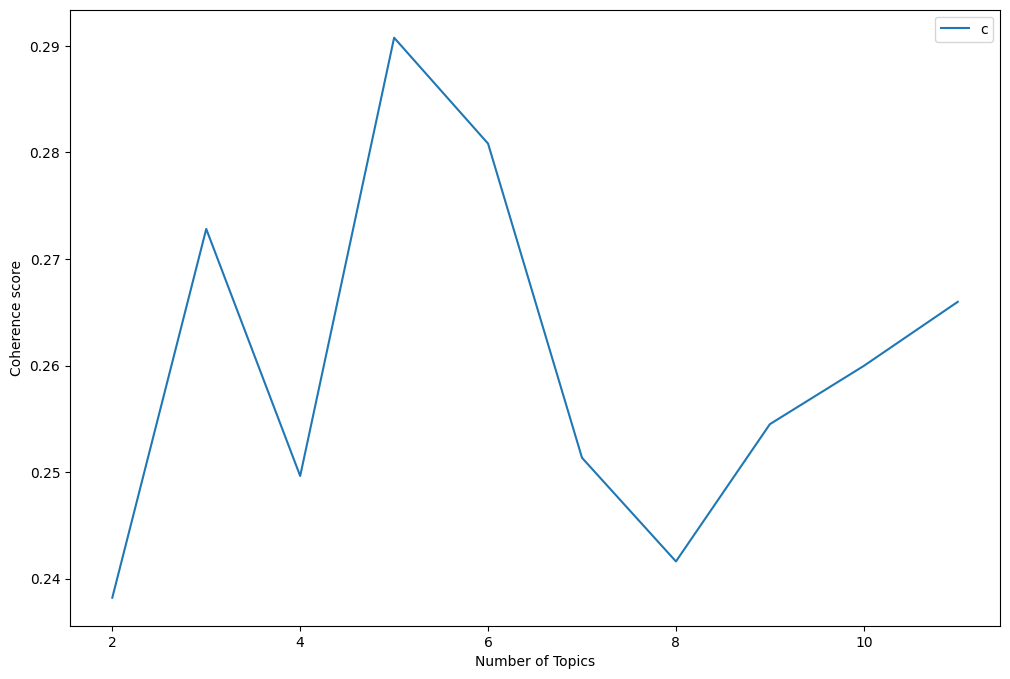

In [45]:
    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()  

In [46]:
lsa_fake = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=5)
lsa_fake.print_topics()

[(0,
  '-0.261*"viral" + -0.261*"circulating" + -0.261*"confirmed" + -0.261*"scientific" + -0.261*"revolutionary" + -0.261*"institution" + -0.261*"discovery" + -0.250*"article" + -0.224*"taken" + -0.224*"manipulated"'),
 (1,
  '-0.295*"image" + -0.295*"taken" + -0.295*"manipulated" + -0.295*"shared" + -0.295*"statement" + -0.295*"appear" + -0.295*"context" + 0.208*"scientific" + 0.208*"institution" + 0.208*"confirmed"'),
 (2,
  '-0.289*"evidence" + -0.289*"headline" + -0.289*"medium" + -0.289*"lack" + -0.289*"spread" + -0.289*"source" + -0.289*"story" + -0.289*"dramatic" + -0.289*"rapidly" + -0.289*"social"'),
 (3,
  '0.387*"despite" + 0.387*"popularity" + 0.387*"report" + 0.387*"official" + 0.387*"validated" + 0.387*"organization" + 0.140*"online" + 0.096*"claim" + -0.095*"viral" + -0.095*"circulating"'),
 (4,
  '0.327*"though" + 0.327*"expert" + 0.327*"blog" + 0.327*"anonymous" + 0.327*"published" + 0.327*"say" + 0.327*"several" + 0.327*"unsupported" + 0.327*"misleading" + 0.133*"inf

## Predecir noticias falsas

In [47]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,Researchers develop improved battery technology,According to an official statement released to...,2016-03-21 0:00:00,Factual News,"[according, official, statement, released, tod...",0.0,neutral
1,New environmental regulations introduced by pa...,"The report includes verified data, statements ...",2020-04-21 0:00:00,Factual News,"[report, includes, verified, data, statement, ...",0.0,neutral
2,"Drinking hot water instantly burns body fat, e...",The story spread rapidly on social media with ...,2020-04-30 0:00:00,Fake News,"[story, spread, rapidly, social, medium, drama...",0.0,neutral
3,Economic growth shows moderate increase this q...,The findings were published in a peer‑reviewed...,2017-11-04 0:00:00,Factual News,"[finding, published, peerreviewed, journal, re...",0.0,neutral
4,Ocean discovered to contain unlimited gold res...,The story spread rapidly on social media with ...,2022-01-10 0:00:00,Fake News,"[story, spread, rapidly, social, medium, drama...",0.0,neutral


In [48]:
X = [','.join(map(str, l)) for l in data['text_clean']]
Y = data['fake_or_factual']

In [49]:
countvec = CountVectorizer()
countvec_fit = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns = countvec.get_feature_names_out())

In [50]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size=0.3)

In [51]:
lr = LogisticRegression(random_state=0).fit(X_train, y_train)

In [52]:
y_pred_lr = lr.predict(X_test)

In [53]:
accuracy_score(y_pred_lr, y_test)

1.0

In [54]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

Factual News       1.00      1.00      1.00        34
   Fake News       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [55]:
svm = SGDClassifier().fit(X_train, y_train)

In [56]:
y_pred_svm = svm.predict(X_test)

In [57]:
accuracy_score(y_pred_svm, y_test)

1.0

In [58]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       1.00      1.00      1.00        34
   Fake News       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

